# Week 7

Finally made the classes done :))

## Phi vals initial fit

In [1]:
from src.api.v4 import HMM, GaussEmission, StaticTransition, AutoregressiveGaussEmission
from src.api.v4 import LBFGSSolver, GradientSolver, Minimizer
import jax.numpy as jnp 
from src.api.v4.utils import phi_to_phi_tilde 

## VALUES FROM TEXTBOOK EXAMPLE
mean = jnp.array([400, 536, 890, 1307]) 
sd = jnp.array([22, 77, 111, 197])  
u0 = jnp.array([0.19, 0.35, 0.15, 0.32])
Gamma = jnp.array([
            [8.5e-01, 1.5e-01, 0.0028, 9.7e-09],
            [8.3e-02, 8.5e-01, 0.0679, 6.8e-09],
            [4.3e-04, 1.6e-01, 0.6842, 1.5e-01],
            [2.6e-08, 6.1e-09, 0.0723, 9.3e-01],]
            )

gauss_emission = GaussEmission.from_params(mu=mean, sigma=sd)
arr_emission = AutoregressiveGaussEmission.from_params(mu=mean, sigma=sd, phi=jnp.array([0.2, 0.4, 0.8, 0.5]))
transition = StaticTransition.from_params(Gamma)

hmm = HMM(transition=transition, emission=gauss_emission, inital_distribution=u0)
ar_hmm = HMM(transition=transition, emission=arr_emission, inital_distribution=u0) 

In [2]:
from src.api.v4.utils import load_y_data

ys = load_y_data() 

In [ ]:



hmm.fit(ys=ys, solver=LBFGSSolver(), frozen={"mu0": False})
ar_hmm.fit(ys=ys, solver=LBFGSSolver(), frozen={"mu0": False})


In [4]:
print(f"Phi vals for AR HMM: {ar_hmm.emission.phi()}")
print(f"Phi tilde is: {ar_hmm.emission.phi_tilde}")
print(f"log likelihood for AR HMM: {ar_hmm.log_likelihood()}")

Phi vals for AR HMM: [[0.2580024  0.44656682 0.8969114  0.7361872 ]]
Phi tilde is: [[0.5279343  0.96080744 2.9123945  1.8842069 ]]
log likelihood for AR HMM: -9571.310546875


### We now build a log likehood plot and test different optimizers

In [5]:
ar_hmm = HMM(transition=transition, emission=arr_emission, inital_distribution=u0) 

START_PHI_TILDE = 0.50
END_PHI_TILDE = 0.55
NUM_POINTS = 30
idx = (0,0)


phi_tilde_param = jnp.linspace(START_PHI_TILDE, END_PHI_TILDE, num=NUM_POINTS)
phi_tilde_param


Array([0.5       , 0.5017241 , 0.5034483 , 0.50517243, 0.50689656,
       0.5086207 , 0.51034486, 0.512069  , 0.5137931 , 0.51551723,
       0.51724136, 0.51896554, 0.52068967, 0.5224138 , 0.5241379 ,
       0.5258621 , 0.5275862 , 0.52931035, 0.5310345 , 0.53275865,
       0.5344828 , 0.5362069 , 0.5379311 , 0.5396552 , 0.54137933,
       0.54310346, 0.5448276 , 0.54655176, 0.5482759 , 0.55      ],      dtype=float32)

In [8]:
original_params = ar_hmm.params 

solvers = {
    "LBFGS": {
        "solver": LBFGSSolver(), 
        "likehood_values": [], 
    },
    "Gradient": {
        "solver": GradientSolver(), 
        "likehood_values": []
    },
    "Minimizer": {
        "solver": Minimizer(),
        "likehood_values": []
    }
}





for phi in phi_tilde_param:
    for solver_name, solver_info in solvers.items():
        ar_hmm.params = original_params  # Reset to original parameters 
        ar_hmm.update_param("phi_tilde", phi, index=idx) 
        ar_hmm.fit(ys=ys, solver=solver_info["solver"], frozen={"phi_tilde": idx, "mu0": False})  
        likehood = ar_hmm.log_likelihood()
        solver_info["likehood_values"].append(likehood)
    



/Users/madshaakonsson/Desktop/5. Semester/special/hmm-code/.venv/lib/python3.11/site-packages/jaxopt/_src/scipy_wrappers.py:341: RuntimeWarning: Method Nelder-Mead does not use gradient information (jac).
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


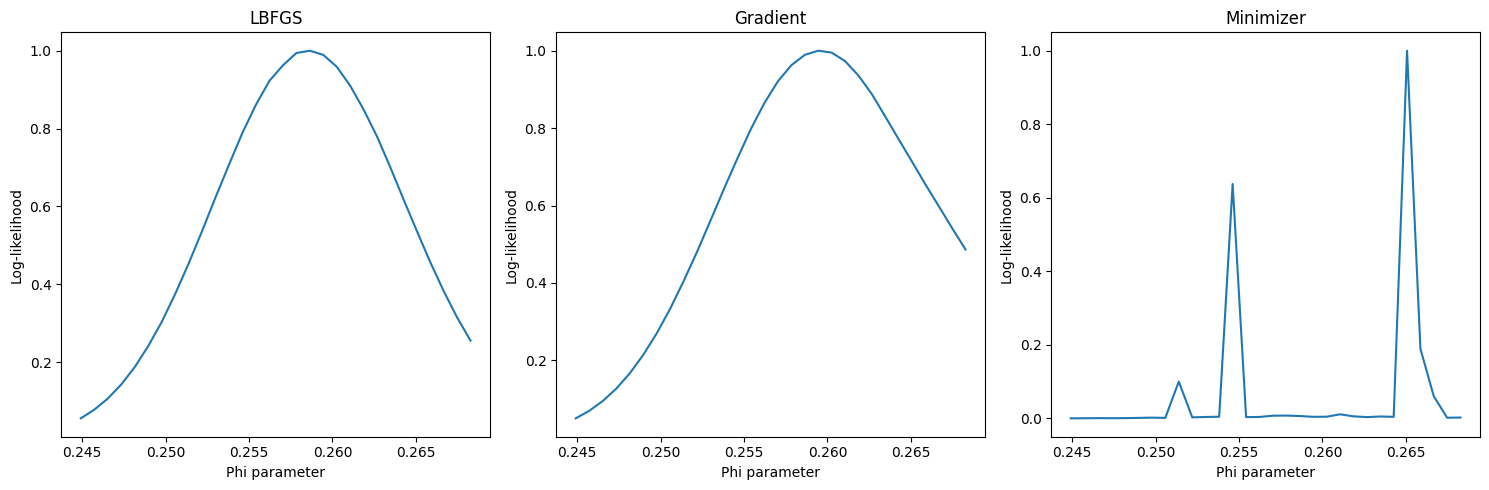

In [9]:
import matplotlib.pyplot as plt
from src.api.v4.utils import phi_tilde_to_phi

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (solver_name, solver_info) in zip(axes, solvers.items()):
    ll_fits = jnp.asarray(solver_info["likehood_values"])
    likelihood_history = jnp.exp(ll_fits - jnp.max(ll_fits))
    
    ax.plot(phi_tilde_to_phi(phi_tilde_param), likelihood_history)
    ax.set_xlabel("Phi parameter")
    ax.set_ylabel("Log-likelihood")
    ax.set_title(solver_name)

fig.tight_layout()
plt.show()

### We now do it for a higher order markov chain 

In [11]:
from src.api.v4 import StaticTransitionHigherOrder

logits = ar_hmm.transition.transition_logits[:, 0]

transition_matrix = StaticTransitionHigherOrder(transition_logits=logits, order = 2, num_states=2) 
gauss_emission = GaussEmission.from_params(mu=mean, sigma=sd)
hmm_order_2 = HMM(transition=transition_matrix, emission=gauss_emission) 

print("Transition matrix for order 2 HMM:")
print(hmm_order_2.transition.transition_matrix())
print(hmm_order_2._compute_stationary_distribution())

Transition matrix for order 2 HMM:
[[1.5042119e-01 8.4957886e-01 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 8.9046232e-02 9.1095376e-01]
 [0.0000000e+00 0.0000000e+00 6.2318845e-04 9.9937683e-01]
 [2.8026328e-08 1.0000000e+00 0.0000000e+00 0.0000000e+00]]
[[-2.9802322e-08  4.7867468e-01  4.2650759e-02  4.7867465e-01]]


[ 272  273  274 ... 1663 1664 1665]


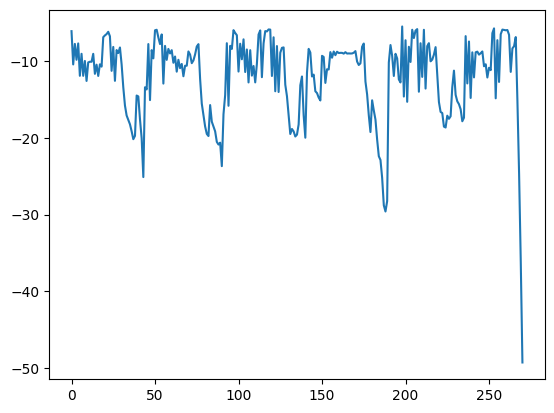

In [31]:
from src.api.v4 import ForwardAlgorithm
params = hmm_order_2.params 
alg = ForwardAlgorithm() 
u0 = hmm_order_2._compute_stationary_distribution() 

output = alg.run(params, u0, ys)

nan_ids = jnp.where(jnp.isnan(output.ft))[0]
print(nan_ids)
import matplotlib.pyplot as plt 

plt.plot(jnp.log(output.ft))

[]


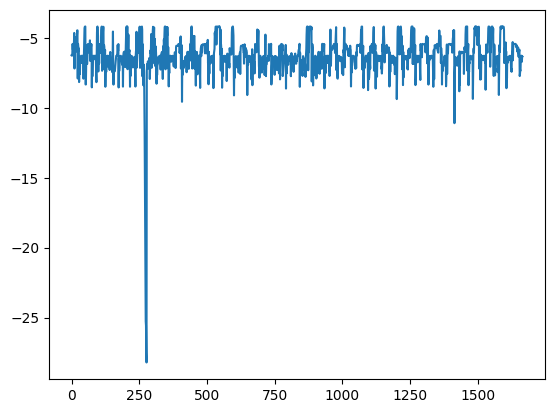

In [32]:

params = hmm.params
alg = ForwardAlgorithm() 
u0 = hmm_order_2._compute_stationary_distribution() 

output = alg.run(params, u0, ys)

nan_ids = jnp.where(jnp.isnan(output.ft))[0]
print(nan_ids)

plt.plot(jnp.log(output.ft))

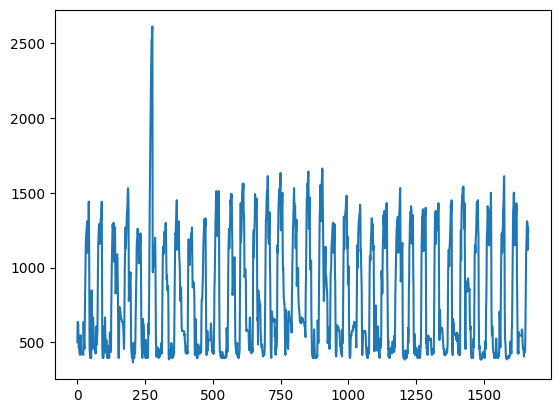

In [29]:
plt.plot(ys) 


In [10]:
hmm_order_2.fit(ys=ys, solver=GradientSolver(), frozen={"mu0": False}) 

print("Transition matrix for order 2 HMM after fitting:")

print(hmm_order_2.transition.transition_matrix())

Transition matrix for order 2 HMM after fitting:
[[nan nan nan nan]
 [nan nan nan nan]
 [nan nan nan nan]
 [nan nan nan nan]]
